# E-Commerce Sales Analysis

**Refactored exploratory data analysis of e-commerce performance.**

This notebook analyses sales, product, geographic, and customer-experience
metrics for a configurable period (default: the full year 2023, compared
with 2022). All data preparation lives in `data_loader.py` and all metric
calculations live in `business_metrics.py`, so this notebook reads as a
narrative of business questions and answers.


## Table of Contents

1. [Introduction and Business Objectives](#1-introduction-and-business-objectives)
2. [Data Dictionary](#2-data-dictionary)
3. [Configuration](#3-configuration)
4. [Data Loading](#4-data-loading)
5. [Data Preparation and Transformation](#5-data-preparation-and-transformation)
6. [Business Metrics](#6-business-metrics)
   - [6.1 Revenue Analysis](#61-revenue-analysis)
   - [6.2 Product Analysis](#62-product-analysis)
   - [6.3 Geographic Analysis](#63-geographic-analysis)
   - [6.4 Customer Experience Analysis](#64-customer-experience-analysis)
7. [Summary of Observations](#7-summary-of-observations)


## 1. Introduction and Business Objectives

The business wants to understand how the store performed over a given period
and how that compares with the previous year. This analysis answers:

- **Revenue:** How much revenue was generated, how does it compare year over
  year, and how does it trend month to month?
- **Order economics:** What is the average order value and the total number
  of orders, and how have they changed?
- **Products:** Which product categories drive the most revenue?
- **Geography:** How is revenue distributed across customer states?
- **Customer experience:** How do customers rate their orders, how fast are
  deliveries, and how does delivery speed relate to review scores?

Revenue metrics are based on **delivered** orders only, so they reflect
realised rather than booked revenue.


## 2. Data Dictionary

The analysis draws on six raw tables in `ecommerce_data/`. The key columns
and derived fields used below are:

| Column | Source | Description |
| --- | --- | --- |
| `order_id` | orders, order_items | Unique identifier for an order |
| `customer_id` | orders, customers | Identifier linking an order to a customer |
| `order_status` | orders | Lifecycle status; analysis keeps `delivered` |
| `order_purchase_timestamp` | orders | When the order was placed (drives the period filter) |
| `order_delivered_customer_date` | orders | When the order reached the customer |
| `price` | order_items | Item price in USD (excludes freight); revenue is the sum of this |
| `product_id` | order_items, products | Identifier for the purchased product |
| `product_category_name` | products | Product category |
| `customer_state` | customers | US state of the customer |
| `review_score` | order_reviews | Customer rating from 1 (worst) to 5 (best) |

**Derived fields** (added in `data_loader.py`):

| Field | Definition |
| --- | --- |
| `year`, `month` | Calendar year and month of `order_purchase_timestamp` |
| `delivery_days` | Days between purchase and delivery to the customer |

**Business terms**

- **Revenue:** Sum of item `price` over delivered order items (freight excluded).
- **Average order value (AOV):** Mean of per-order total price.
- **Month-over-month growth:** Mean of the month-to-month percentage changes
  in revenue across the period.
- **Year-over-year (YoY) growth:** Percentage change of a metric versus the
  same period in the prior year.


## 3. Configuration

All analysis parameters are set here. Change these values to run the entire
notebook for any period; every downstream cell respects them. The defaults
reproduce the original analysis (full-year 2023 versus 2022).


In [1]:
# Analysis period configuration
ANALYSIS_YEAR = 2023
ANALYSIS_MONTHS = None      # None = all months; e.g. [1, 2, 3] for Q1
COMPARISON_YEAR = 2022      # None to skip year-over-year comparison

DATA_DIR = "ecommerce_data"

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px

import data_loader as dl
import business_metrics as bm

# Consistent, business-oriented styling for all matplotlib charts.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Color scheme: a single primary for headline series, a muted accent for
# comparisons, and a sequential scale for ranked categories/maps.
PRIMARY = "#1f4e79"       # deep navy
ACCENT = "#c55a11"        # muted orange
SEQUENTIAL = "Blues"      # sequential scale for ranked bars / choropleth


def month_label(months):
    """Human-readable description of the configured month range."""
    if not months:
        return "Jan-Dec"
    names = ["", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
             "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    months = sorted(months)
    return f"{names[months[0]]}-{names[months[-1]]}"


PERIOD_LABEL = f"{month_label(ANALYSIS_MONTHS)} {ANALYSIS_YEAR}"
print(f"Analysis period: {PERIOD_LABEL}")
if COMPARISON_YEAR:
    print(f"Comparison period: {month_label(ANALYSIS_MONTHS)} {COMPARISON_YEAR}")

Analysis period: Jan-Dec 2023
Comparison period: Jan-Dec 2022


## 4. Data Loading

`EcommerceData.load()` reads the six raw CSV files and builds a single
enriched, item-level sales table of delivered orders. The same loaded object
is reused for every analysis below.


In [3]:
data = dl.EcommerceData(DATA_DIR).load()

print("Raw tables loaded:")
for name, frame in data.raw.items():
    print(f"  {name:<12} {frame.shape[0]:>6} rows x {frame.shape[1]} cols")

print(f"\nEnriched delivered-sales table: {data.sales.shape[0]} rows x "
      f"{data.sales.shape[1]} cols")
data.sales.head()

Raw tables loaded:
  orders        10000 rows x 8 cols
  order_items   16047 rows x 7 cols
  products       6000 rows x 9 cols
  customers      8000 rows x 5 cols
  reviews        6571 rows x 7 cols
  payments      14091 rows x 5 cols

Enriched delivered-sales table: 15095 rows x 14 cols


,order_id,order_item_id,product_id,price,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,year,month,delivery_days,product_category_name,customer_state,review_score
0,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6,grocery_gourmet_food,TN,5.0
1,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6,electronics,TN,5.0
2,ord_0a02a8a1d3d282380ed7d0cc,1,prod_d5f7b6e420ea5cffc504ab21,1030.31,cust_157f0ea0316c546ac08dae30,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,2022,5,7,home_garden,IL,NaN
3,ord_0a02a8a1d3d282380ed7d0cc,2,prod_01b00f21c2758bf94f51234f,1299.50,cust_157f0ea0316c546ac08dae30,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,2022,5,7,home_garden,IL,NaN
4,ord_8a243422e3ad7ab97a1fe175,1,prod_a904d724d4b2b8f571e66f19,1307.04,cust_bd21648bc4c95ae7aad6bda7,delivered,2022-04-18 15:02:44.122280,2022-04-30 16:02:44.122280,2022,4,12,home_garden,MI,3.0


## 5. Data Preparation and Transformation

The enriched table is produced by `data_loader.py` through these steps:

1. **Join** order items to their parent orders on `order_id`.
2. **Filter** to `delivered` orders so revenue reflects fulfilled sales.
3. **Parse** purchase and delivery timestamps to datetime.
4. **Derive** `year`, `month`, and `delivery_days`.
5. **Enrich** with product category, customer state, and review score.

Because join keys (`product_id`, `customer_id`, `order_id` in reviews) are
unique, enrichment does not duplicate sales rows. The period filter below is
applied to `order_purchase_timestamp` via the derived `year`/`month` columns.


In [4]:
# Focus period and (optional) comparison period.
sales = data.filter_sales(year=ANALYSIS_YEAR, months=ANALYSIS_MONTHS)

comparison = None
if COMPARISON_YEAR:
    comparison = data.filter_sales(year=COMPARISON_YEAR, months=ANALYSIS_MONTHS)

print(f"{PERIOD_LABEL}: {len(sales)} sales rows, "
      f"{bm.total_orders(sales)} orders")
if comparison is not None:
    print(f"{month_label(ANALYSIS_MONTHS)} {COMPARISON_YEAR}: "
          f"{len(comparison)} sales rows, {bm.total_orders(comparison)} orders")

Jan-Dec 2023: 7448 sales rows, 4635 orders
Jan-Dec 2022: 7641 sales rows, 4749 orders


## 6. Business Metrics

Headline figures for the period, with year-over-year comparison where a
comparison year is configured.


In [5]:
summary = bm.period_summary(sales, comparison)

print(f"Headline metrics for {PERIOD_LABEL}")
print("-" * 40)
print(f"Total revenue:        ${summary['total_revenue']:,.2f}")
print(f"Total orders:         {summary['total_orders']:,}")
print(f"Average order value:  ${summary['average_order_value']:,.2f}")
print(f"Mean monthly growth:  {summary['mean_monthly_growth'] * 100:.2f}%")
print(f"Average review score:  {summary['average_review_score']:.2f} / 5")
print(f"Average delivery time: {summary['average_delivery_time']:.2f} days")

if comparison is not None:
    print(f"\nYear-over-year vs {COMPARISON_YEAR}")
    print("-" * 40)
    print(f"Revenue growth: {summary['revenue_growth'] * 100:.2f}%")
    print(f"Orders growth:  {summary['orders_growth'] * 100:.2f}%")
    print(f"AOV growth:     {summary['aov_growth'] * 100:.2f}%")

Headline metrics for Jan-Dec 2023
----------------------------------------
Total revenue:        $3,360,294.74
Total orders:         4,635
Average order value:  $724.98
Mean monthly growth:  -0.39%
Average review score:  4.10 / 5
Average delivery time: 8.01 days

Year-over-year vs 2022
----------------------------------------
Revenue growth: -2.46%
Orders growth:  -2.40%
AOV growth:     -0.06%


### 6.1 Revenue Analysis

Total revenue, year-over-year change, and the month-over-month revenue trend.


In [6]:
revenue = bm.total_revenue(sales)
print(f"Total revenue for {PERIOD_LABEL}: ${revenue:,.2f}")

if comparison is not None:
    yoy = bm.growth_rate(revenue, bm.total_revenue(comparison))
    print(f"Versus {COMPARISON_YEAR}: {yoy * 100:.2f}%")

Total revenue for Jan-Dec 2023: $3,360,294.74
Versus 2022: -2.46%


In [7]:
# Month-over-month growth rates across the period.
growth = bm.monthly_growth(sales)
print("Month-over-month revenue growth:")
print((growth * 100).round(2).to_string())
print(f"\nMean month-over-month growth: "
      f"{bm.mean_monthly_growth(sales) * 100:.2f}%")

Month-over-month revenue growth:
month
1       NaN
2     -2.84
3      3.20
4    -11.14
5     18.74
6     -4.06
7      2.45
8     -3.23
9      5.98
10   -14.45
11    -0.14
12     1.24

Mean month-over-month growth: -0.39%


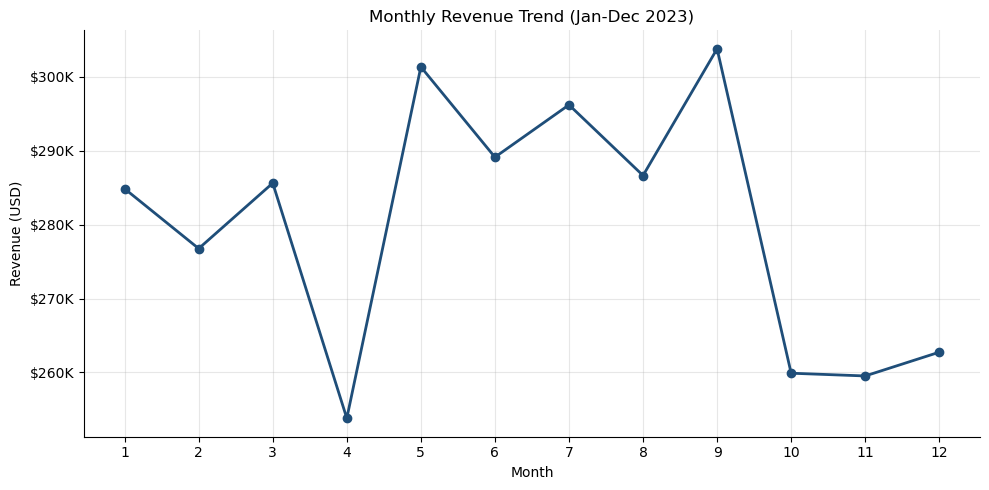

In [8]:
# Monthly revenue trend.
monthly = bm.monthly_revenue(sales)

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, marker="o", color=PRIMARY, linewidth=2)
ax.set_title(f"Monthly Revenue Trend ({PERIOD_LABEL})")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.tight_layout()
plt.show()

### 6.2 Product Analysis

Revenue by product category, ranked from highest to lowest.


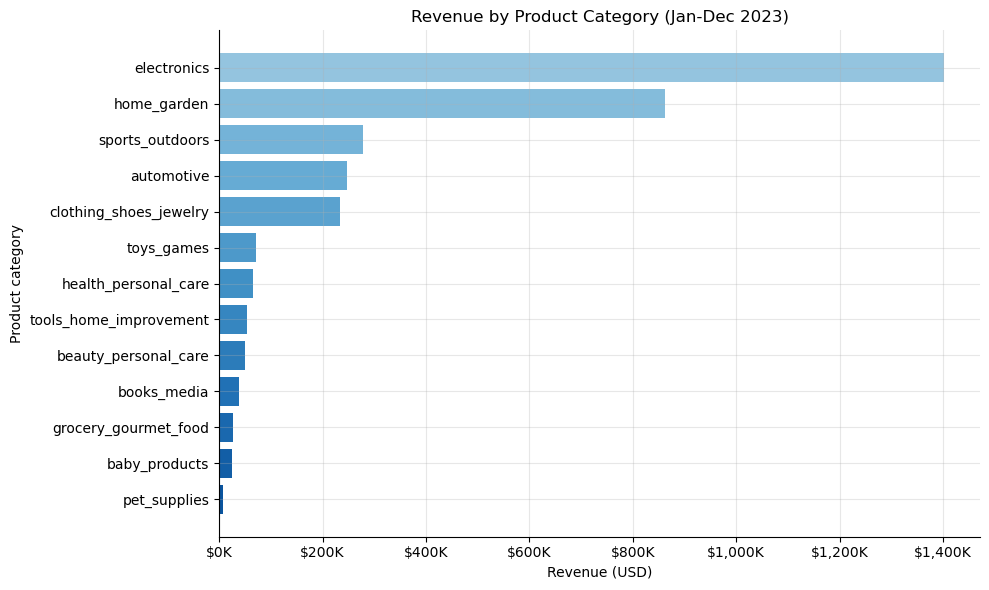

In [9]:
category_revenue = bm.revenue_by_category(sales)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = mpl.colormaps[SEQUENTIAL]
colors = cmap(
    [0.4 + 0.5 * i / len(category_revenue) for i in range(len(category_revenue))][::-1]
)
ax.barh(category_revenue.index[::-1], category_revenue.values[::-1], color=colors)
ax.set_title(f"Revenue by Product Category ({PERIOD_LABEL})")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Product category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.tight_layout()
plt.show()

### 6.3 Geographic Analysis

Revenue distribution across US customer states.


In [10]:
state_revenue = bm.revenue_by_state(sales)

fig = px.choropleth(
    state_revenue,
    locations="customer_state",
    color="price",
    locationmode="USA-states",
    scope="usa",
    color_continuous_scale=SEQUENTIAL,
    labels={"price": "Revenue (USD)", "customer_state": "State"},
    title=f"Revenue by State ({PERIOD_LABEL})",
)
fig.update_layout(coloraxis_colorbar_title="Revenue (USD)")
fig.show()

### 6.4 Customer Experience Analysis

Review score distribution, average delivery time, the relationship between
delivery speed and review score, and the overall order-status mix.
Customer-experience metrics are based on orders that received a review.


In [11]:
avg_review = bm.average_review_score(sales)
avg_delivery = bm.average_delivery_time(sales)
print(f"Average review score for {PERIOD_LABEL}: {avg_review:.2f} / 5")
print(f"Average delivery time for {PERIOD_LABEL}: {avg_delivery:.2f} days")

Average review score for Jan-Dec 2023: 4.10 / 5
Average delivery time for Jan-Dec 2023: 8.01 days


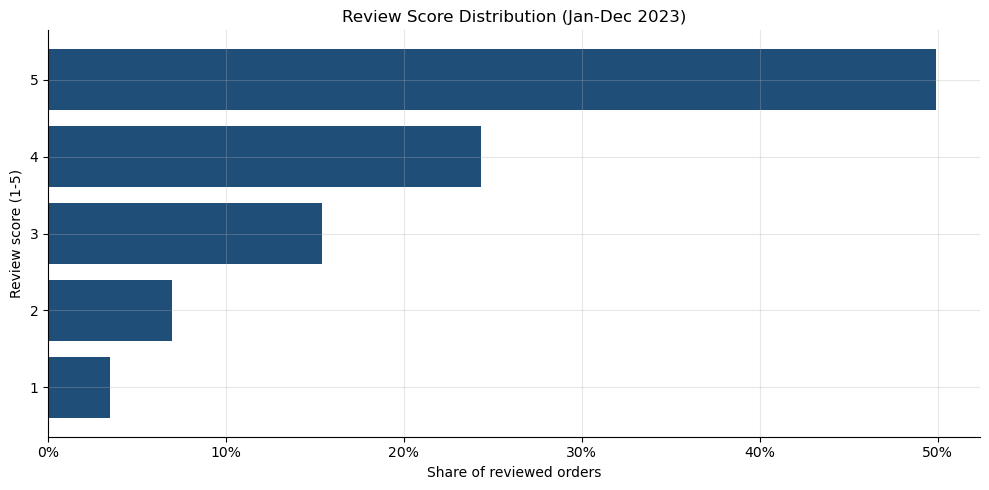

In [12]:
# Review score distribution.
distribution = bm.review_score_distribution(sales)

fig, ax = plt.subplots()
ax.barh(distribution.index.astype(int).astype(str), distribution.values, color=PRIMARY)
ax.set_title(f"Review Score Distribution ({PERIOD_LABEL})")
ax.set_xlabel("Share of reviewed orders")
ax.set_ylabel("Review score (1-5)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [13]:
# Average review score for each exact delivery time (days).
day_review = bm.review_score_by_delivery_day(sales)
print("Average review score by delivery time (days):")
print(day_review.round(4).to_string(index=False))

Average review score by delivery time (days):
 delivery_days  review_score
             2        4.0339
             3        4.2486
             4        4.0680
             5        4.0541
             6        4.0735
             7        4.1022
             8        3.9654
             9        4.1175
            10        4.1009
            11        4.1466
            12        4.2521
            13        4.0994
            14        4.1754
            15        4.0000


delivery_time  review_score
     1-3 days      4.193966
     4-7 days      4.075063
      8+ days      4.108138


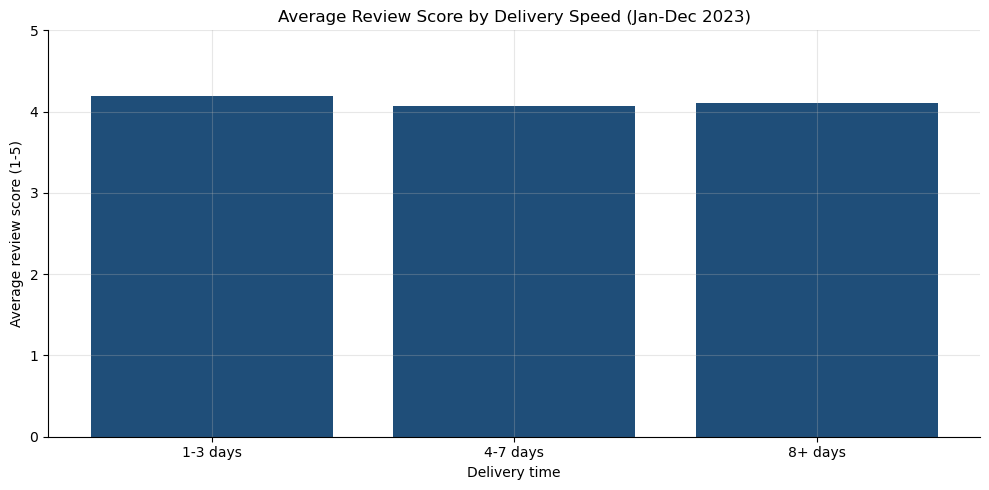

In [14]:
# Average review score by delivery-speed bucket.
speed_review = bm.review_score_by_delivery_speed(sales)
print(speed_review.to_string(index=False))

fig, ax = plt.subplots()
ax.bar(speed_review["delivery_time"].astype(str), speed_review["review_score"],
       color=PRIMARY)
ax.set_title(f"Average Review Score by Delivery Speed ({PERIOD_LABEL})")
ax.set_xlabel("Delivery time")
ax.set_ylabel("Average review score (1-5)")
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

Order status distribution (Jan-Dec 2023):
order_status
delivered     93.64
shipped        3.19
canceled       1.29
processing     1.19
pending        0.51
returned       0.18


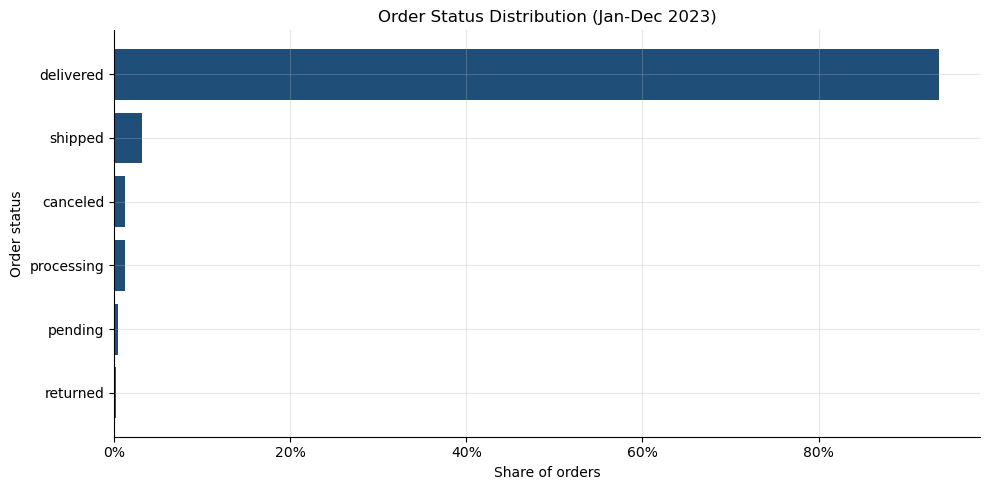

In [15]:
# Order-status mix for the period (all statuses, not only delivered).
orders_period = dl.filter_by_period(
    data.orders_with_dates(), year=ANALYSIS_YEAR, months=ANALYSIS_MONTHS
)
status_mix = bm.order_status_distribution(orders_period)
print(f"Order status distribution ({PERIOD_LABEL}):")
print((status_mix * 100).round(2).to_string())

fig, ax = plt.subplots()
ax.barh(status_mix.index[::-1], status_mix.values[::-1], color=PRIMARY)
ax.set_title(f"Order Status Distribution ({PERIOD_LABEL})")
ax.set_xlabel("Share of orders")
ax.set_ylabel("Order status")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 7. Summary of Observations

The recap below is generated from the configured period, so it stays correct
if the configuration changes. The narrative that follows describes the
default period (full-year 2023 versus 2022).


In [16]:
# Configuration-driven recap of the headline figures.
print(f"Observations for {PERIOD_LABEL}")
print("=" * 45)
print(f"Total revenue:         ${summary['total_revenue']:,.2f}")
print(f"Total orders:          {summary['total_orders']:,}")
print(f"Average order value:   ${summary['average_order_value']:,.2f}")
print(f"Mean monthly growth:   {summary['mean_monthly_growth'] * 100:.2f}%")
print(f"Average review score:  {summary['average_review_score']:.2f} / 5")
print(f"Average delivery time: {summary['average_delivery_time']:.2f} days")
if comparison is not None:
    print(f"\nYear-over-year vs {COMPARISON_YEAR}")
    print(f"  Revenue: {summary['revenue_growth'] * 100:.2f}%   "
          f"Orders: {summary['orders_growth'] * 100:.2f}%   "
          f"AOV: {summary['aov_growth'] * 100:.2f}%")

Observations for Jan-Dec 2023
Total revenue:         $3,360,294.74
Total orders:          4,635
Average order value:   $724.98
Mean monthly growth:   -0.39%
Average review score:  4.10 / 5
Average delivery time: 8.01 days

Year-over-year vs 2022
  Revenue: -2.46%   Orders: -2.40%   AOV: -0.06%


**Default period narrative (full-year 2023 versus 2022)**

**Revenue**

- Total 2023 revenue was about $3.36M, roughly 2.5% lower than 2022.
- The mean month-over-month growth rate was slightly negative (about -0.39%),
  and the monthly trend fluctuates without a sustained direction.

**Order economics**

- Average order value (about $725) was essentially flat year over year
  (about -0.06%).
- The number of delivered orders (4,635) fell about 2.4% versus 2022,
  accounting for most of the revenue decline.

**Products**

- Revenue is spread across the product categories, with the ranking shown in
  the category chart identifying the largest contributors.

**Geography**

- Revenue varies by customer state, as visualised in the choropleth map.

**Customer experience**

- The average review score was about 4.10 out of 5, with most reviewed orders
  rating 4 or 5.
- The average delivery time among reviewed orders was about 8 days.
- Review scores are similar across delivery-speed buckets, with the 1-3 day
  bucket scoring marginally highest.
- The large majority of orders reached `delivered` status.

These observations are descriptive; thresholds for what counts as "good" or
"bad" performance are intentionally left to the business.
